In [1]:
import torch
import matplotlib.pyplot as plt


x = torch.tensor([0,1,2,3,4,5,6,7.])
y = torch.tensor([1.86, 1.31, .62, .33, .09, -.67, -1.23, -1.37])
m = torch.tensor([0.9])
b = torch.tensor([0.1])

def regression(my_m,my_x,my_b):
    return (my_m*my_x)+my_b
def mse(my_yhat,my_y):
    sigma = torch.sum((my_yhat-my_y)**2)
    return sigma/len(my_y)


y_hat = regression(m,x,b)
C = mse(y_hat,y)

### Math Explaination
C = sigma((yhat-y)**2)/n  
assuming u = yhat-y  
so C = sigma(u**2)/n  
  
del C / del yhat = del C /del u * del u /del yhat  

u = yhat - y  
del u /del yhat = 1  
  
so del C /del yhat = del C / del u  
  
del C /del yhat = 2/n*sigma(yhat-y)  

as we know yhat = m *x + b  
so ,  
del yhat / del m = x  
del yhat / del b = 1  

therefore ,  
del C /del m = del C / del yhat * del yhat / del m  
del C /del b = del C /del yhat * del yhat / del b  
so applying all above ,  
del C /del m = 2/n * sigma((yhat-y)*x)
del C / del b = 2/n * sigma(yhat-y)*1

In [2]:
def del_c_del_m(my_yhat,my_y,my_x):
    return (2/len(my_y))*torch.sum((my_yhat-my_y)*my_x)

In [3]:
def del_c_del_b(my_yhat,my_y):
    return (2/len(my_y))*torch.sum(my_yhat-my_y)

def update_params(my_m,my_b,my_mgrad,my_bgrad,learning_rate):
    return my_m-(learning_rate*my_mgrad),my_b-(learning_rate*my_bgrad)

In [4]:
def reg_plot(my_x,my_y,my_m,my_b,my_c,my_mgrad,my_bgrad,include_grad=True):
    title = f"C = {my_c.item()}"
    
    if include_grad:
        xlabel = f"m = {my_m.item()},m Grad = {my_mgrad.item()}"
        ylabel = f"b = {my_b.item()},b Grad = {my_bgrad.item()}"
    else:
        xlabel = f"m = {my_m.item()}"
        ylabel = f"b = {my_b.item()}" 
    
    fig,ax = plt.subplots()
    
    ax.scatter(my_x,my_y)
    
    x_min,x_max = ax.get_xlim()
    y_min,y_max = my_m*x_min + my_b,my_m*x_max + my_b
    ax.set_xlim([x_min,x_max])
    ax.plot([x_min,x_max],[y_min.item(),y_max.item()])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

epoch = 0,C = 19.675472259521484 , m = 0.5369499921798706 , b = 0.03735000640153885 , mgrad = 36.304996490478516, bgrad = 6.2649993896484375
epoch = 100,C = 0.3467177152633667 , m = -0.258194237947464 , b = 0.7219290733337402 , mgrad = 0.12241095304489136, bgrad = -0.6019721031188965
epoch = 200,C = 0.12242075800895691 , m = -0.35088539123535156 , b = 1.1777504682540894 , mgrad = 0.06865954399108887, bgrad = -0.33764371275901794
epoch = 300,C = 0.05185599625110626 , m = -0.40287551283836365 , b = 1.433418869972229 , mgrad = 0.03851047158241272, bgrad = -0.1893828958272934
epoch = 400,C = 0.029656123369932175 , m = -0.432036429643631 , b = 1.5768215656280518 , mgrad = 0.02160005271434784, bgrad = -0.10622440278530121
epoch = 500,C = 0.02267191931605339 , m = -0.44839268922805786 , b = 1.6572556495666504 , mgrad = 0.012114688754081726, bgrad = -0.05958114564418793
epoch = 600,C = 0.020474644377827644 , m = -0.45756685733795166 , b = 1.7023710012435913 , mgrad = 0.006796345114707947, bgra

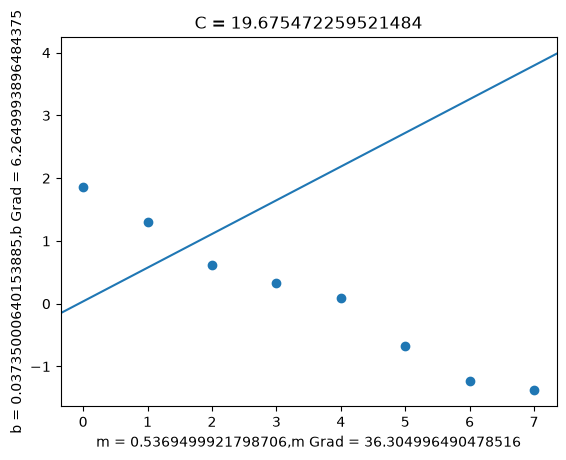

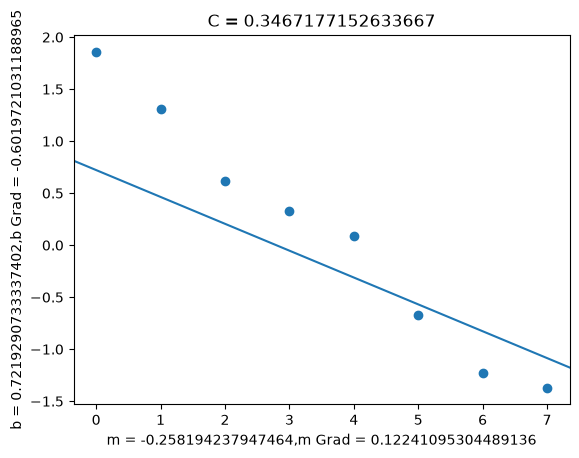

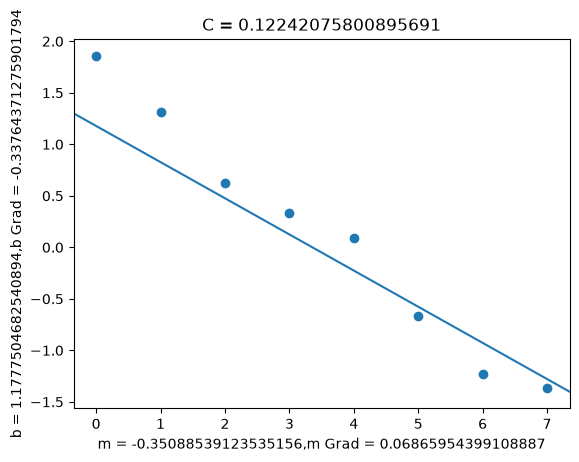

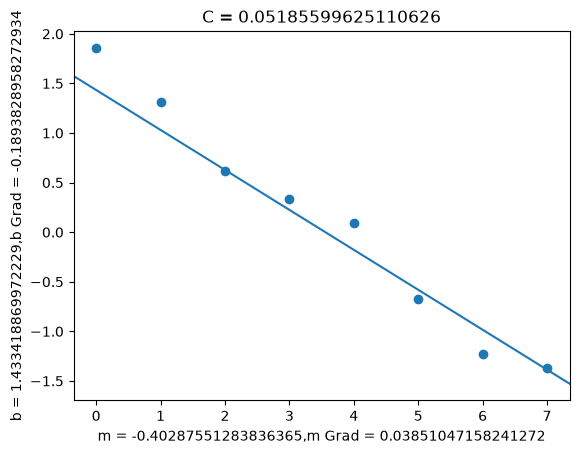

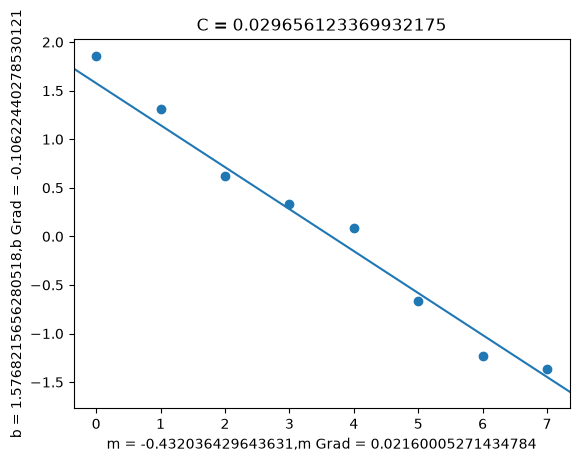

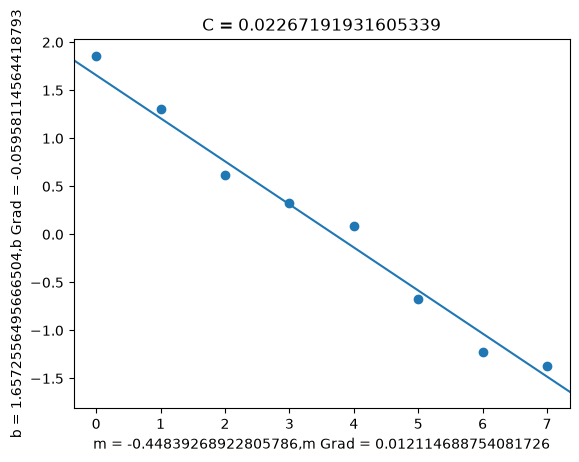

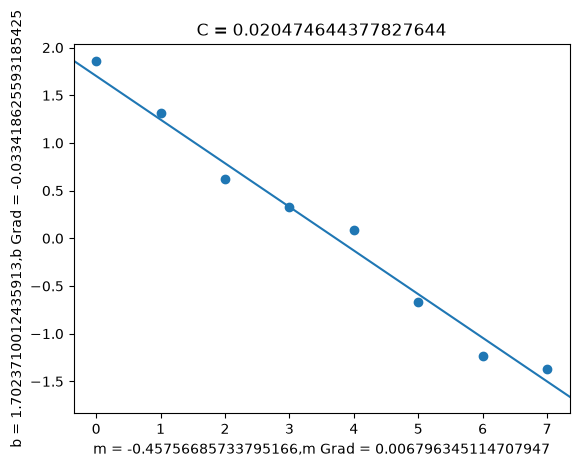

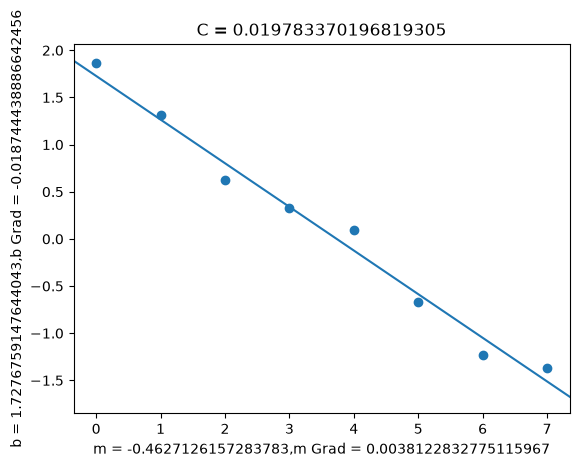

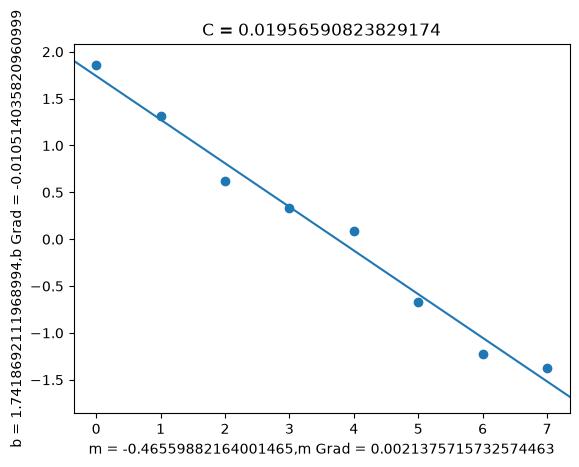

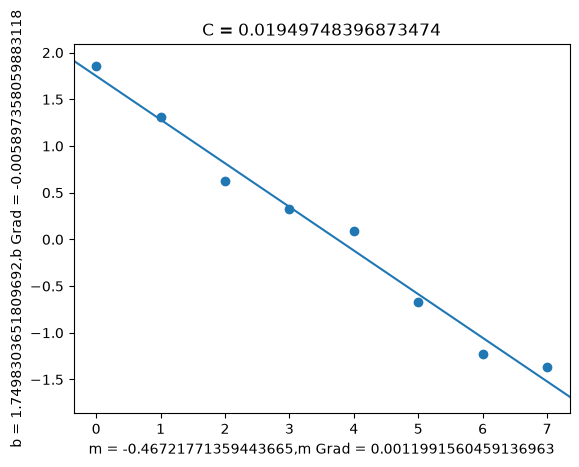

In [5]:
epochs = 1000
learning_rate = 0.01
for epoch in range(epochs):
    
    y_hat = regression(m,x,b)
    C = mse(y_hat,y)
    
    mgrad = del_c_del_m(y_hat,y,x)
    bgrad = del_c_del_b(y_hat,y)
    
    m,b = update_params(m,b,mgrad,bgrad,learning_rate)
    
    if epoch%100 ==0 :
        reg_plot(x,y,m,b,C,mgrad,bgrad,)
        print(f"epoch = {epoch},C = {C.item()} , m = {m.item()} , b = {b.item()} , mgrad = {mgrad.item()}, bgrad = {bgrad.item()}")